Aerial Damage Detection with CNNs

In this notebook you will build, train, and interpret a <strong>Convolutional Neural Network (CNN) that classifies aerial images as <em>damaged</em> or <em>undamaged</em>. The notebook is organized into three phases, each designed to build on the last:


    Phase 1 — Learning<br><span style="font-weight:normal; font-size:13px;">Load data, build a CNN, train it, and evaluate performance. This is the standard supervised-learning pipeline.</span>

    Phase 2 — Exploring Architecture<br><span style="font-weight:normal; font-size:13px;">Open up the trained model and visualize what each layer actually learns — filters, feature maps, and pooling.</span>

    Phase 3 — Understanding Predictions (LIME)<br><span style="font-weight:normal; font-size:13px;">Use LIME to explain <em>why</em> the model made a specific prediction by highlighting which regions of an image mattered most.

In [1]:
#import sys
#!{sys.executable} -m pip install numpy matplotlib seaborn torch torchvision scikit-learn scikit-image lime

Imports & Configurations

In [16]:
import os
from collections import defaultdict
import math
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import patches
from matplotlib.offsetbox import AnchoredText
import seaborn as sns

# deep learning (PyTorch)
import torch                                    
import torch.nn as nn                           
import torch.optim as optim                     
import torch.nn.functional as F                 
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models  
# evaluation
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc  
# explainability
from skimage.segmentation import slic, mark_boundaries        
from lime import lime_image                    

Hyperparameters & Settings

In [17]:
Transfer_Learning = False

DATA_DIR = Path("images")
IMG_SIZE = 64
BATCH_SIZE = 32
NUM_EPOCHS = 15
LEARNING_RATE = 1e-4

DATA_SIZER = .5

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
MODEL_SAVE_PATH = "damage_detector.pth"

Using device: mps


Data Transforms

In [18]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

Loading the Data

In [19]:
train_dataset_full = datasets.ImageFolder(DATA_DIR / "train", transform=train_transform)
val_dataset_full   = datasets.ImageFolder(DATA_DIR / "validate", transform=eval_transform)
test_dataset       = datasets.ImageFolder(DATA_DIR / "test", transform=eval_transform)

from sklearn.model_selection import train_test_split

train_indices, _ = train_test_split(
    range(len(train_dataset_full)),
    train_size=DATA_SIZER,
    stratify=train_dataset_full.targets,
    random_state=42,
)

val_indices, _ = train_test_split(
    range(len(val_dataset_full)),
    train_size=DATA_SIZER,
    stratify=val_dataset_full.targets,
    random_state=42,
)

train_dataset = Subset(train_dataset_full, train_indices)
val_dataset   = Subset(val_dataset_full, val_indices)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

class_names = train_dataset_full.classes
print(f"classes: {class_names}")
print(f"crain: {len(train_dataset)} | val: {len(val_dataset)} | test: {len(test_dataset)}")

Classes: ['a_no_damage', 'b_damage']
Train: 5000 | Val: 1000 | Test: 2515


In [20]:
def extract_coords(filename):
    name = os.path.splitext(filename)[0]
    parts = name.replace('-', '_').split('_')

    for i in range(len(parts) - 1):
        try:
            lat = float(parts[i])
            lon = float(parts[i + 1])
            return f"{lat:.5f}_{lon:.5f}"
        except ValueError:
            continue
    return None

test_dir = DATA_DIR / "test"
class_dirs = sorted(os.listdir(test_dir)) 

coord_map = defaultdict(dict)

for idx, (path, label) in enumerate(test_dataset.samples):
    fname = os.path.basename(path)
    class_name = class_dirs[label]
    coord = extract_coords(fname)
    if coord:
        coord_map[coord][class_name] = {"index": idx, "filename": fname}

pairs = []
for coord, classes in coord_map.items():
    if len(classes) == len(class_dirs):  # present in all classes
        pairs.append({
            "coordinate": coord,
            **{f"{cls}_idx": classes[cls]["index"] for cls in class_dirs},
            **{f"{cls}_file": classes[cls]["filename"] for cls in class_dirs},
        })

print(f"total test images: {len(test_dataset)}")
print(f"images with parseable coordinates: {sum(len(v) for v in coord_map.values())}")
print(f"perfect pairs found: {len(pairs)}")

Total test images: 2515
Images with parseable coordinates: 2515
Perfect pairs found: 118


Model Architecture

In [21]:
if Transfer_Learning:
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    for param in model.parameters():
        param.requires_grad = False
    
    model.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(model.fc.in_features, 1),
    )
    model = model.to(DEVICE)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.fc.parameters(), lr=LEARNING_RATE)



else:
    model = nn.Sequential(
        nn.Conv2d(3, 16, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2),
        nn.Conv2d(16, 32, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2),
        nn.Conv2d(32, 64, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.AdaptiveAvgPool2d(1),
        nn.Flatten(),
        nn.Linear(64, 32), 
        nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(32, 1), 
    ).to(DEVICE)
        
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=3, factor=0.5)


Training & Evaluation Functions

In [22]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.float().to(DEVICE)

        optimizer.zero_grad()
        
        outputs = model(images).view(-1) 
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = (outputs >= 0.0).float()
        
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total



def evaluate(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.float().to(DEVICE)
            
            outputs = model(images).view(-1) 
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            
            preds = (outputs >= 0.0).float()
            
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total


Training Loop

In [23]:
best_val_loss = float("inf")
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = evaluate(model, val_loader, criterion)
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.3f} | "
          f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.3f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print(f"Saved best model (val_loss={val_loss:.4f})")

Epoch 01/15 | Train Loss: 0.6903  Acc: 0.501 | Val Loss: 0.6824  Acc: 0.500
Saved best model (val_loss=0.6824)
Epoch 02/15 | Train Loss: 0.6591  Acc: 0.602 | Val Loss: 0.6071  Acc: 0.773
Saved best model (val_loss=0.6071)
Epoch 03/15 | Train Loss: 0.5731  Acc: 0.719 | Val Loss: 0.4995  Acc: 0.837
Saved best model (val_loss=0.4995)
Epoch 04/15 | Train Loss: 0.5110  Acc: 0.761 | Val Loss: 0.4914  Acc: 0.794
Saved best model (val_loss=0.4914)
Epoch 05/15 | Train Loss: 0.4926  Acc: 0.777 | Val Loss: 0.4722  Acc: 0.798
Saved best model (val_loss=0.4722)
Epoch 06/15 | Train Loss: 0.4750  Acc: 0.786 | Val Loss: 0.5009  Acc: 0.755
Epoch 07/15 | Train Loss: 0.4637  Acc: 0.791 | Val Loss: 0.4654  Acc: 0.798
Saved best model (val_loss=0.4654)
Epoch 08/15 | Train Loss: 0.4649  Acc: 0.786 | Val Loss: 0.4384  Acc: 0.824
Saved best model (val_loss=0.4384)
Epoch 09/15 | Train Loss: 0.4576  Acc: 0.794 | Val Loss: 0.5170  Acc: 0.733
Epoch 10/15 | Train Loss: 0.4442  Acc: 0.804 | Val Loss: 0.4016  Acc: 0

Training Curves

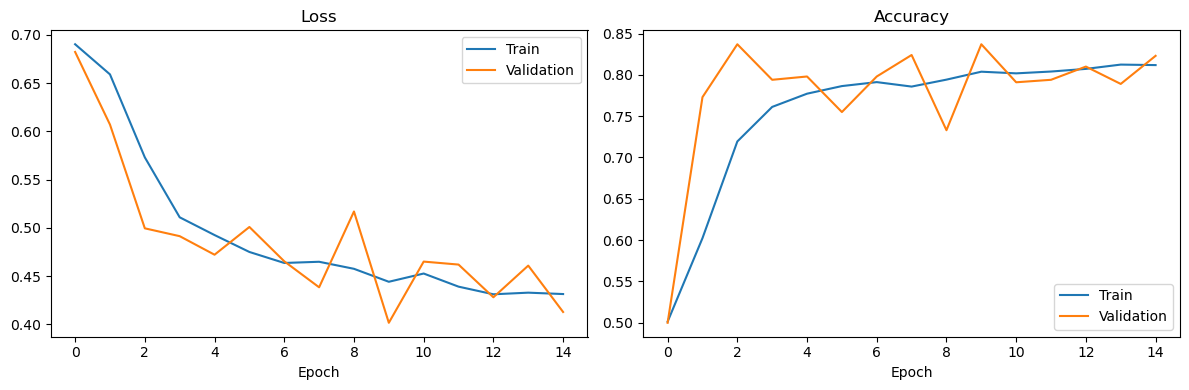

In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history["train_loss"], label="Train")
ax1.plot(history["val_loss"], label="Validation")
ax1.set_title("Loss"); ax1.set_xlabel("Epoch"); ax1.legend()

ax2.plot(history["train_acc"], label="Train")
ax2.plot(history["val_acc"], label="Validation")
ax2.set_title("Accuracy"); ax2.set_xlabel("Epoch"); ax2.legend()

plt.tight_layout()
#plt.savefig("training_curves.png", dpi=150)
plt.show()

Test Set Evaluation

Test Loss: 0.3685 | Test Accuracy: 0.869

Classification Report:
              precision    recall  f1-score   support

 a_no_damage       0.93      0.72      0.82      1000
    b_damage       0.84      0.96      0.90      1515

    accuracy                           0.87      2515
   macro avg       0.89      0.84      0.86      2515
weighted avg       0.88      0.87      0.87      2515



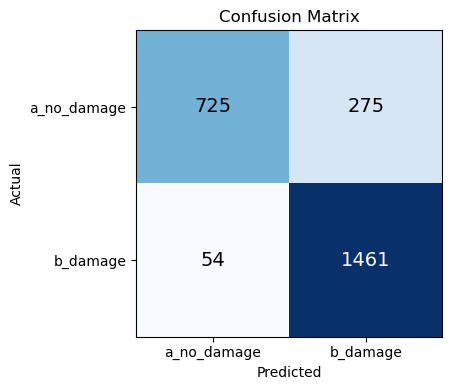

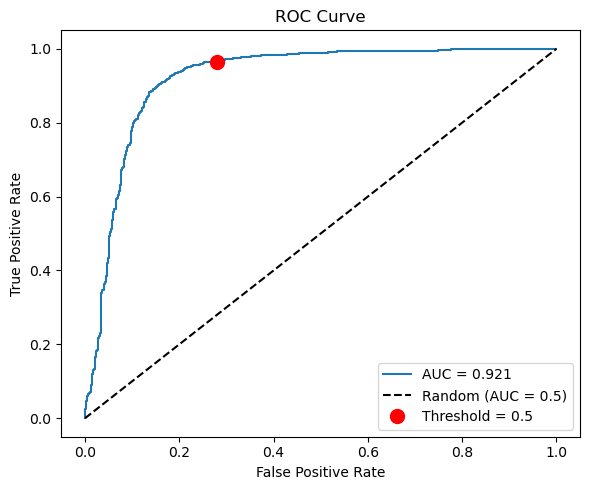

In [25]:
model.load_state_dict(torch.load(MODEL_SAVE_PATH, weights_only=True))
test_loss, test_acc = evaluate(model, test_loader, criterion)
print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.3f}")
print(f"{'='*50}")

all_probs, all_labels, all_images = [], [], []
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        outputs = model(images).squeeze(1)
        probs = torch.sigmoid(outputs).cpu()
        all_probs.extend(probs.numpy())
        all_labels.extend(labels.numpy())
        all_images.extend(images)

all_preds = [1 if p >= 0.5 else 0 for p in all_probs]
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(class_names)
ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix")

for i in range(2):
    for j in range(2):
        color = "white" if cm[i, j] > cm.max() / 2 else "black"
        ax.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=14, color=color)
plt.tight_layout()
#plt.savefig("Confusion_Matrix.pdf")
plt.show()

fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

idx_05 = np.argmin(np.abs(thresholds - 0.5))

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], "k--", label="Random (AUC = 0.5)")
plt.plot(fpr[idx_05], tpr[idx_05], 'ro', markersize=10,
         label=f"Threshold = 0.5")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
#plt.savefig("ROC_curve.pdf")
plt.show()

Looking Inside the Trained Model

In [26]:
activations = {}

def get_activation(name):
    def hook(model, input, output):
        activations[name] = output.detach().cpu()
    return hook

if Transfer_Learning:
    model.conv1.register_forward_hook(get_activation('conv1'))
    model.layer1.register_forward_hook(get_activation('conv2'))
    model.layer2.register_forward_hook(get_activation('conv3'))
else:

    model[0].register_forward_hook(get_activation('conv1'))
    model[3].register_forward_hook(get_activation('conv2'))
    model[6].register_forward_hook(get_activation('conv3'))

image, label = test_dataset[1]
model.eval()
with torch.no_grad():
    input_batch = image.unsqueeze(0).to(DEVICE)
    _ = model(input_batch)

Reversing Normalization for Display

In [27]:
def get_display_image(tensor_img):
    img = tensor_img.cpu().clone().numpy()
    img = img.transpose((1, 2, 0))

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = img * std + mean

    return np.clip(img, 0, 1)

img_display = get_display_image(test_dataset[1][0])

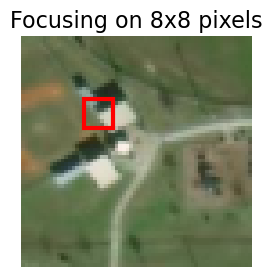

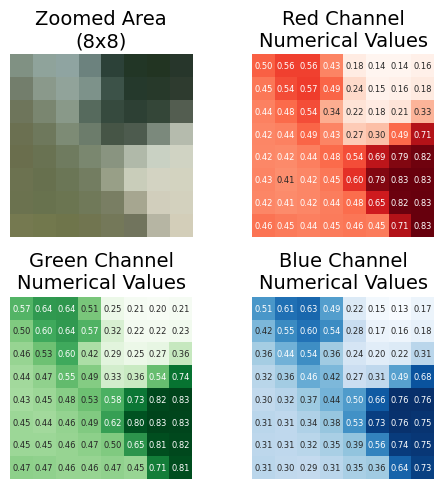

In [28]:

def plot_cnn_step_by_step(img_full, size=16):
    
    start = 17
    fig1, ax1 = plt.subplots(figsize=(3, 3))
    ax1.imshow(img_full)
    
    rect = patches.Rectangle((start, start), size, size, linewidth=3, edgecolor='red', facecolor='none')
    ax1.add_patch(rect)
    
    ax1.set_title(f"Focusing on {size}x{size} pixels", fontsize=16)
    ax1.axis('off')
    #plt.savefig("image_zoomed.pdf")
    plt.show()

    img_crop = img_full[start:start+size, start:start+size, :]

    fig2, axes = plt.subplots(2, 2, figsize=(5, 5))
    
    axes[0,0].imshow(img_crop, interpolation='nearest')
    axes[0,0].set_title(f"Zoomed Area\n({size}x{size})", fontsize=14)
    axes[0,0].axis('off')

    channels = ["Red Channel", "Green Channel", "Blue Channel"]
    cmaps = ["Reds", "Greens", "Blues"]
    
    
    ax_list = [axes[0, 0], axes[0, 1], axes[1, 0], axes[1, 1]]
    
    for i, (title, cmap) in enumerate(zip(channels, cmaps)):
        ax = ax_list[i+1]
        patch = img_crop[:, :, i] 
        
        sns.heatmap(
            patch, 
            annot=True, 
            fmt=".2f", 
            cmap=cmap, 
            cbar=False, 
            ax=ax,
            annot_kws={"size": 6}, 
            xticklabels=False,
            yticklabels=False,
            square=True
        )
        ax.set_title(f"{title}\nNumerical Values", fontsize=14)

    #plt.suptitle("How a CNN Sees: From Pixels to Numerical Tensors", fontsize=20, y=1.05)
    plt.tight_layout()
    #plt.savefig("CNN_first_tensor.pdf")
    plt.show()
    return  img_crop

img_crop =plot_cnn_step_by_step(img_display, size=8)

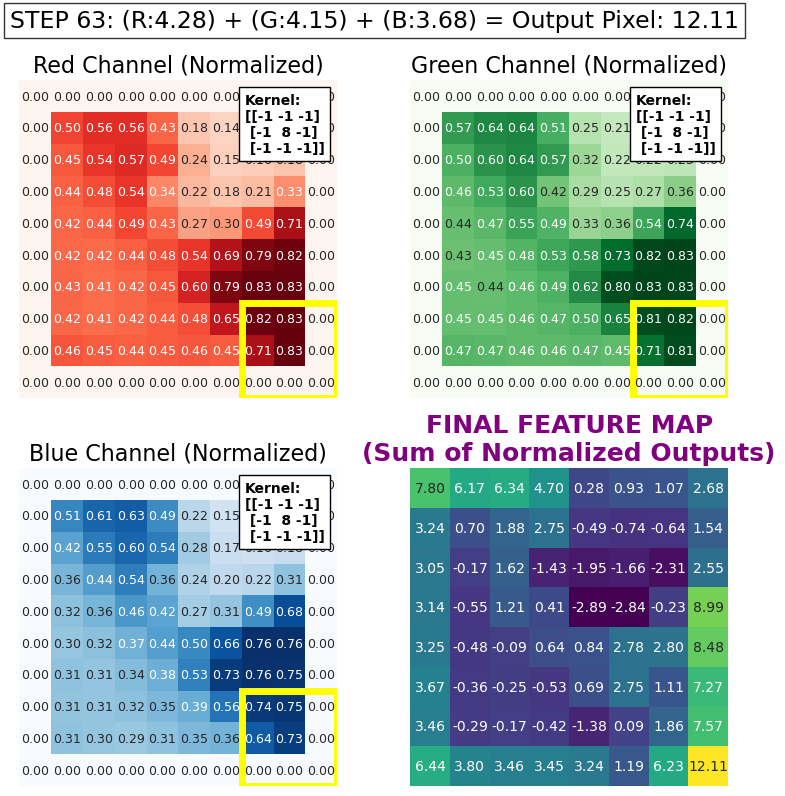

In [29]:
def plot_3d_normalized_slide(img_crop, step=0, kernel_2d=None, use_padding=True):
    if img_crop.max() > 1.01:
        img_crop = img_crop / 255.0
    
    if kernel_2d is None:
        kernel_2d = np.array([[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]])

    if use_padding:
        working_img = np.pad(img_crop, ((1, 1), (1, 1), (0, 0)), mode='constant', constant_values=0)
    else:
        working_img = img_crop

    rows, cols, _ = working_img.shape
    out_size = cols - 2 
    r, c = step // out_size, step % out_size

    fig, axes = plt.subplots(2, 2, figsize=(8, 8))
    channels = ["Red", "Green", "Blue"]
    cmaps = ["Reds", "Greens", "Blues"]
    partial_results = []
    
    ax_list = [axes[0, 0], axes[0, 1], axes[1, 0]]
    
    for i in range(3):
        ax = ax_list[i]
        chan_data = working_img[:, :, i]
        
        sns.heatmap(chan_data, annot=True, fmt=".2f", cmap=cmaps[i], cbar=False, 
                    ax=ax, annot_kws={"size": 9}, xticklabels=False, yticklabels=False, square=True)
        
        rect = plt.Rectangle((c, r), 3, 3, fill=False, edgecolor='yellow', linewidth=5)
        ax.add_patch(rect)
        
        k_text = f"Kernel:\n{kernel_2d}"
        at = AnchoredText(k_text, prop=dict(size=10, weight='bold'), frameon=True, loc='upper right')
        ax.add_artist(at)
        ax.set_title(f"{channels[i]} Channel (Normalized)", fontsize=16)

        window = chan_data[r:r+3, c:c+3]
        partial_results.append(np.sum(window * kernel_2d))

    output_map = np.full((out_size, out_size), np.nan)
    for i in range(step + 1):
        sr, sc = i // out_size, i % out_size
        total = 0
        for ch in range(3):
            total += np.sum(working_img[sr:sr+3, sc:sc+3, ch] * kernel_2d)
        output_map[sr, sc] = total

    ax_out = axes[1, 1]
    sns.heatmap(output_map, annot=True, fmt=".2f", cmap="viridis", cbar=False, 
                ax=ax_out, annot_kws={"size": 10}, xticklabels=False, yticklabels=False, square=True)
    ax_out.set_title("FINAL FEATURE MAP\n(Sum of Normalized Outputs)", fontsize=18, fontweight='bold', color='purple')

    current_total = sum(partial_results)
    title_str = (f"STEP {step}: (R:{partial_results[0]:.2f}) + "
                 f"(G:{partial_results[1]:.2f}) + (B:{partial_results[2]:.2f}) = "
                 f"Output Pixel: {current_total:.2f}")
    
    plt.suptitle(title_str, fontsize=17, y=.99, bbox=dict(facecolor='white', alpha=0.8))
    plt.tight_layout()
    #plt.savefig("step_"+str(step)+"_first_convolution.pdf")
    plt.show()

    return output_map


output_map = plot_3d_normalized_slide(img_crop, step=63, use_padding=True)

ReLU + Max Pooling

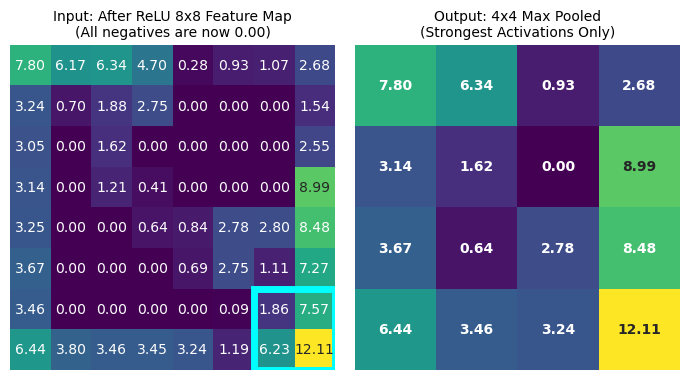

In [30]:
def plot_max_pooling_slide(feature_map, step=0, pool_size=2, use_relu=True):
    """
    Visualizes ReLU + Max Pooling.
    ReLU: max(0, x) 
    Max Pooling: max(window)
    """
    if use_relu:
        feature_map = np.maximum(0, feature_map)
    

    rows, cols = feature_map.shape
    stride = pool_size 
    out_rows, out_cols = rows // stride, cols // stride
    
    r_out, c_out = step // out_cols, step % out_cols
    r_in, c_in = r_out * stride, c_out * stride

    pooled_output = np.full((out_rows, out_cols), np.nan)
    for i in range(step + 1):
        sr_out, sc_out = i // out_cols, i % out_cols
        sr_in, sc_in = sr_out * stride, sc_out * stride
        window = feature_map[sr_in:sr_in+pool_size, sc_in:sc_in+pool_size]
        pooled_output[sr_out, sc_out] = np.max(window)

    fig, axes = plt.subplots(1, 2, figsize=(7, 4))
    
    sns.heatmap(feature_map, annot=True, fmt=".2f", cmap="viridis", cbar=False, 
                ax=axes[0], annot_kws={"size": 10}, xticklabels=False, yticklabels=False, square=True)
    
    rect = plt.Rectangle((c_in, r_in), pool_size, pool_size, fill=False, edgecolor='cyan', linewidth=5)
    axes[0].add_patch(rect)
    title_prefix = "After ReLU " if use_relu else ""
    axes[0].set_title(f"Input: {title_prefix}8x8 Feature Map\n(All negatives are now 0.00)", fontsize=10)

    sns.heatmap(pooled_output, annot=True, fmt=".2f", cmap="viridis", cbar=False, 
                ax=axes[1], annot_kws={"size": 10, "weight": 'bold'}, xticklabels=False, yticklabels=False, square=True)
    axes[1].set_title(f"Output: 4x4 Max Pooled\n(Strongest Activations Only)", fontsize=10)

    current_window = feature_map[r_in:r_in+pool_size, c_in:c_in+pool_size]
    max_val = np.max(current_window)
    #plt.suptitle(f"RELU + MAX POOLING STEP {step}: max({current_window.flatten()}) = {max_val:.2f}", 
    #fontsize=11, y=1.05, bbox=dict(facecolor='white', alpha=0.8))

    plt.tight_layout()
    #plt.savefig(f"step_{step}_max_pool.pdf")
    plt.show()

    return pooled_output


pooled_output = plot_max_pooling_slide(output_map, step=15, use_relu=True)

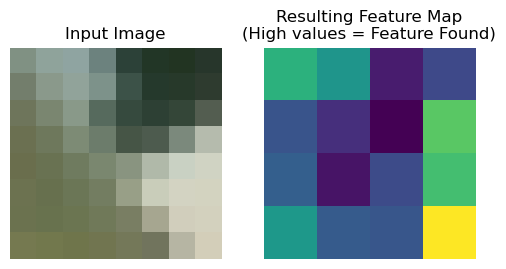

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(6, 3))

axes[0].imshow(img_crop )
axes[0].set_title("Input Image")
    
axes[1].imshow(pooled_output, cmap='viridis')
axes[1].set_title("Resulting Feature Map\n(High values = Feature Found)")
    
for ax in axes: ax.axis('off')
#plt.savefig(f"side_by_side.pdf")
plt.show()


Photo to Feature Vector

In [32]:
NCOLS = 6  
MAX_SLOTS = 36  

def make_filter_grid(feat, title, filename, cmap="viridis", vmin=None, vmax=None):
    f_count = feat.shape[0]
    
    if f_count <= MAX_SLOTS:
        n_show = f_count
        remaining = 0
        n_slots = f_count
    else:
        n_show = MAX_SLOTS - 1
        remaining = f_count - n_show
        n_slots = MAX_SLOTS

    nrows = math.ceil(n_slots / NCOLS)
    fig, axes = plt.subplots(nrows, NCOLS, figsize=(12, nrows * 2.3))
    fig.suptitle(title, fontsize=18, y=1.0)

    for i, ax in enumerate(axes.flatten()):
        if i < n_show:
            ax.imshow(feat[i], cmap=cmap, vmin=vmin, vmax=vmax)
            ax.set_title(f"F{i+1}", fontsize=8)
        elif i == n_show and remaining > 0:
            ax.text(0.5, 0.5, f"+{remaining}\nMORE", transform=ax.transAxes,
                    ha='center', va='center', fontsize=14, fontweight='bold', color='gray')
        ax.axis("off")
    plt.tight_layout()
    #plt.savefig(filename)
    plt.show()

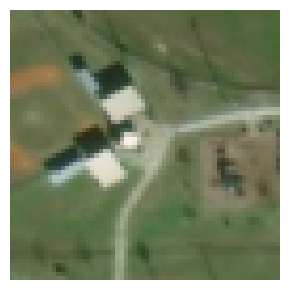

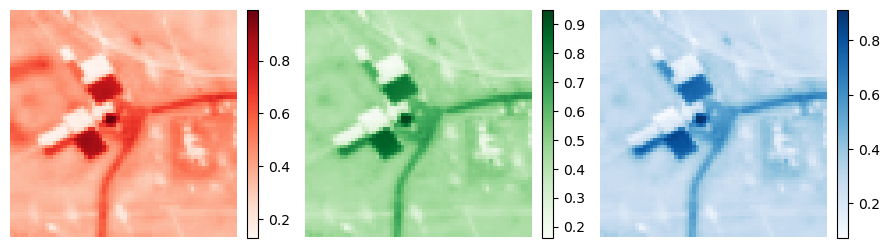

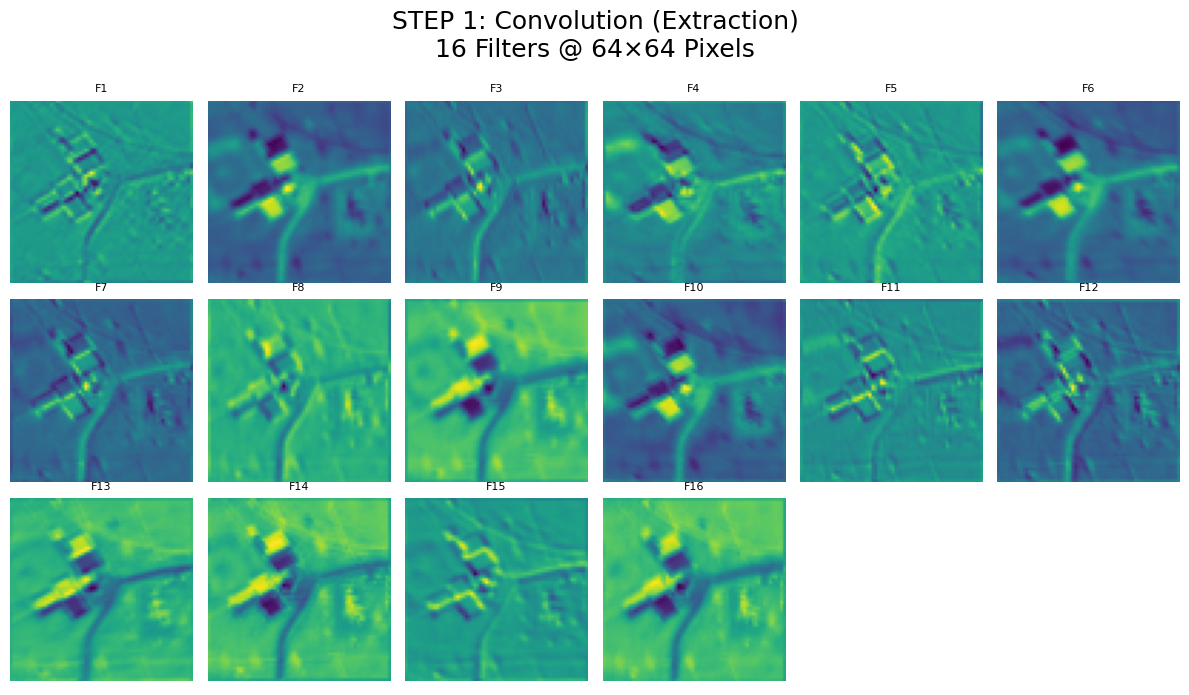

/var/folders/hr/zpgklk8j1l3cqmj16f1f2lnw0000gn/T/ipykernel_18052/791434020.py:33: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  feat_relu = F.relu(torch.tensor(feat_early))


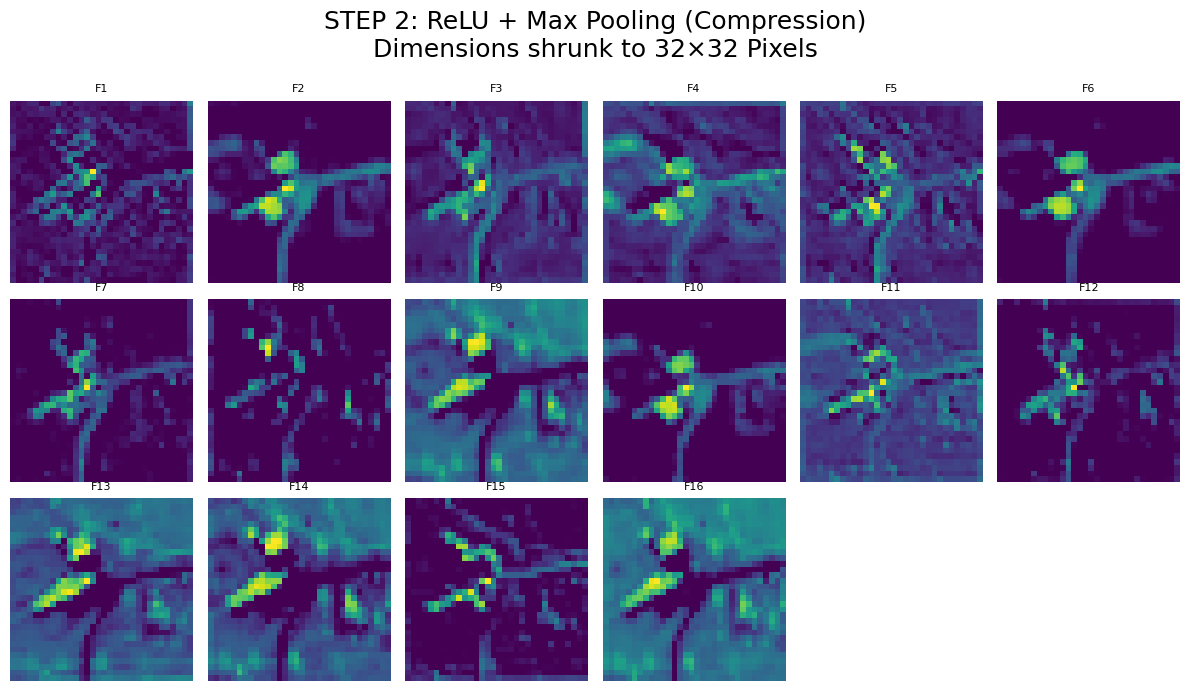

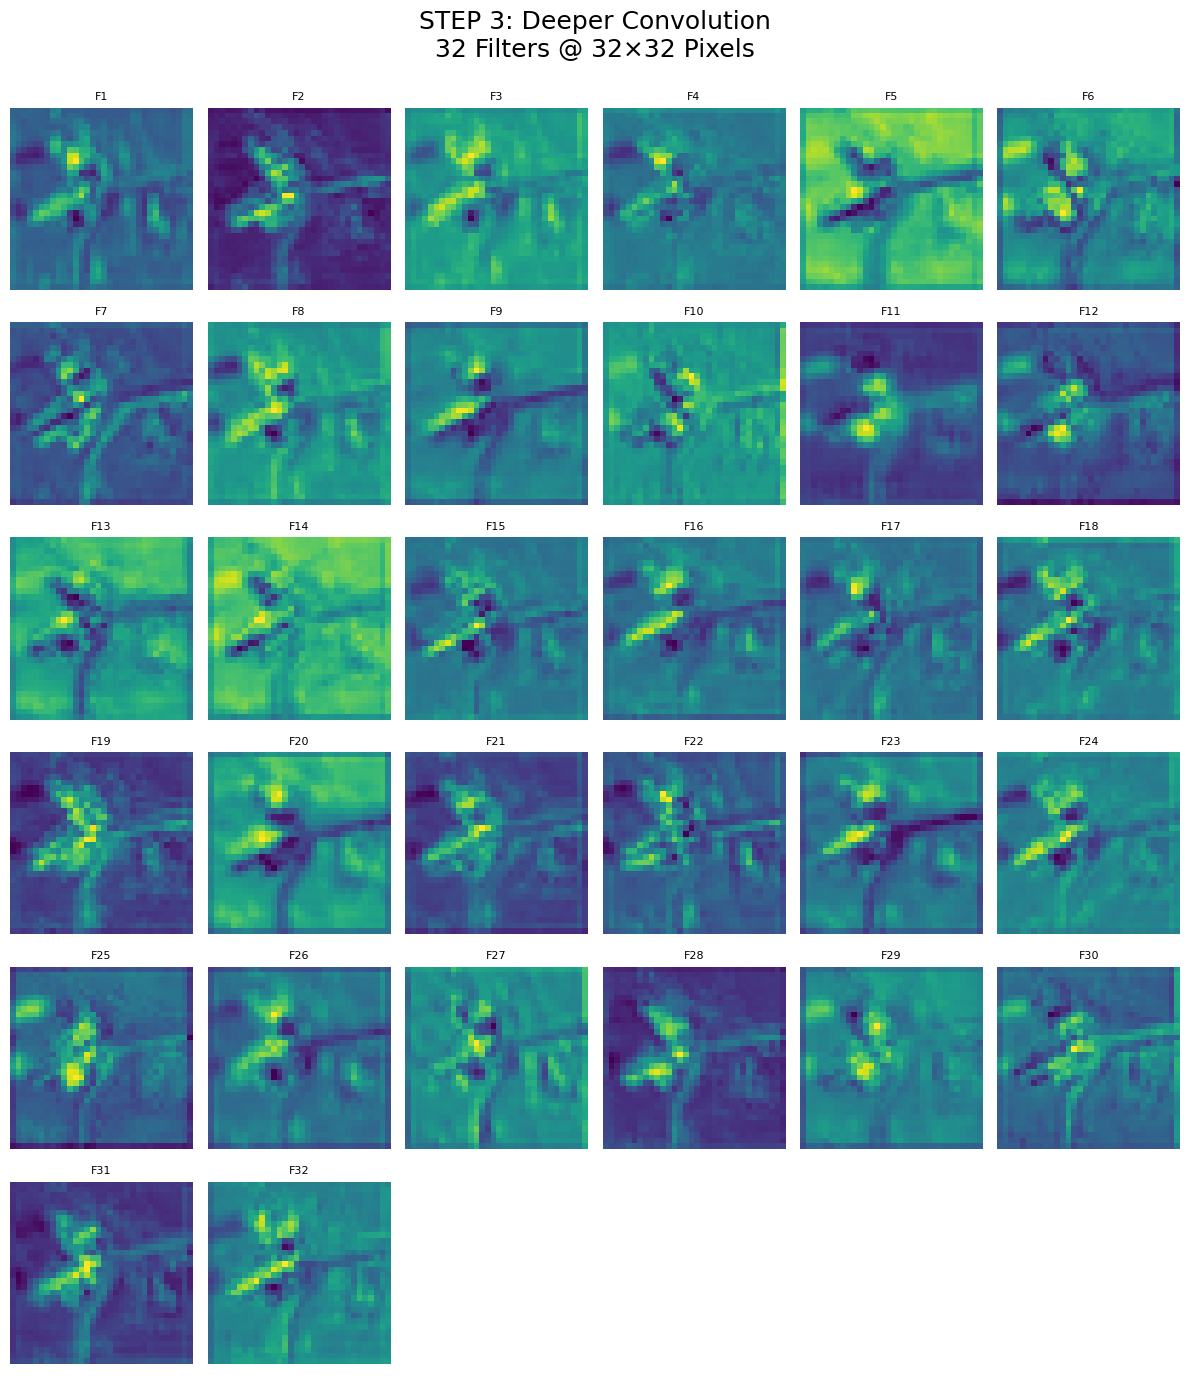

/var/folders/hr/zpgklk8j1l3cqmj16f1f2lnw0000gn/T/ipykernel_18052/791434020.py:51: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  feat_deep_relu = F.relu(torch.tensor(feat_deep))


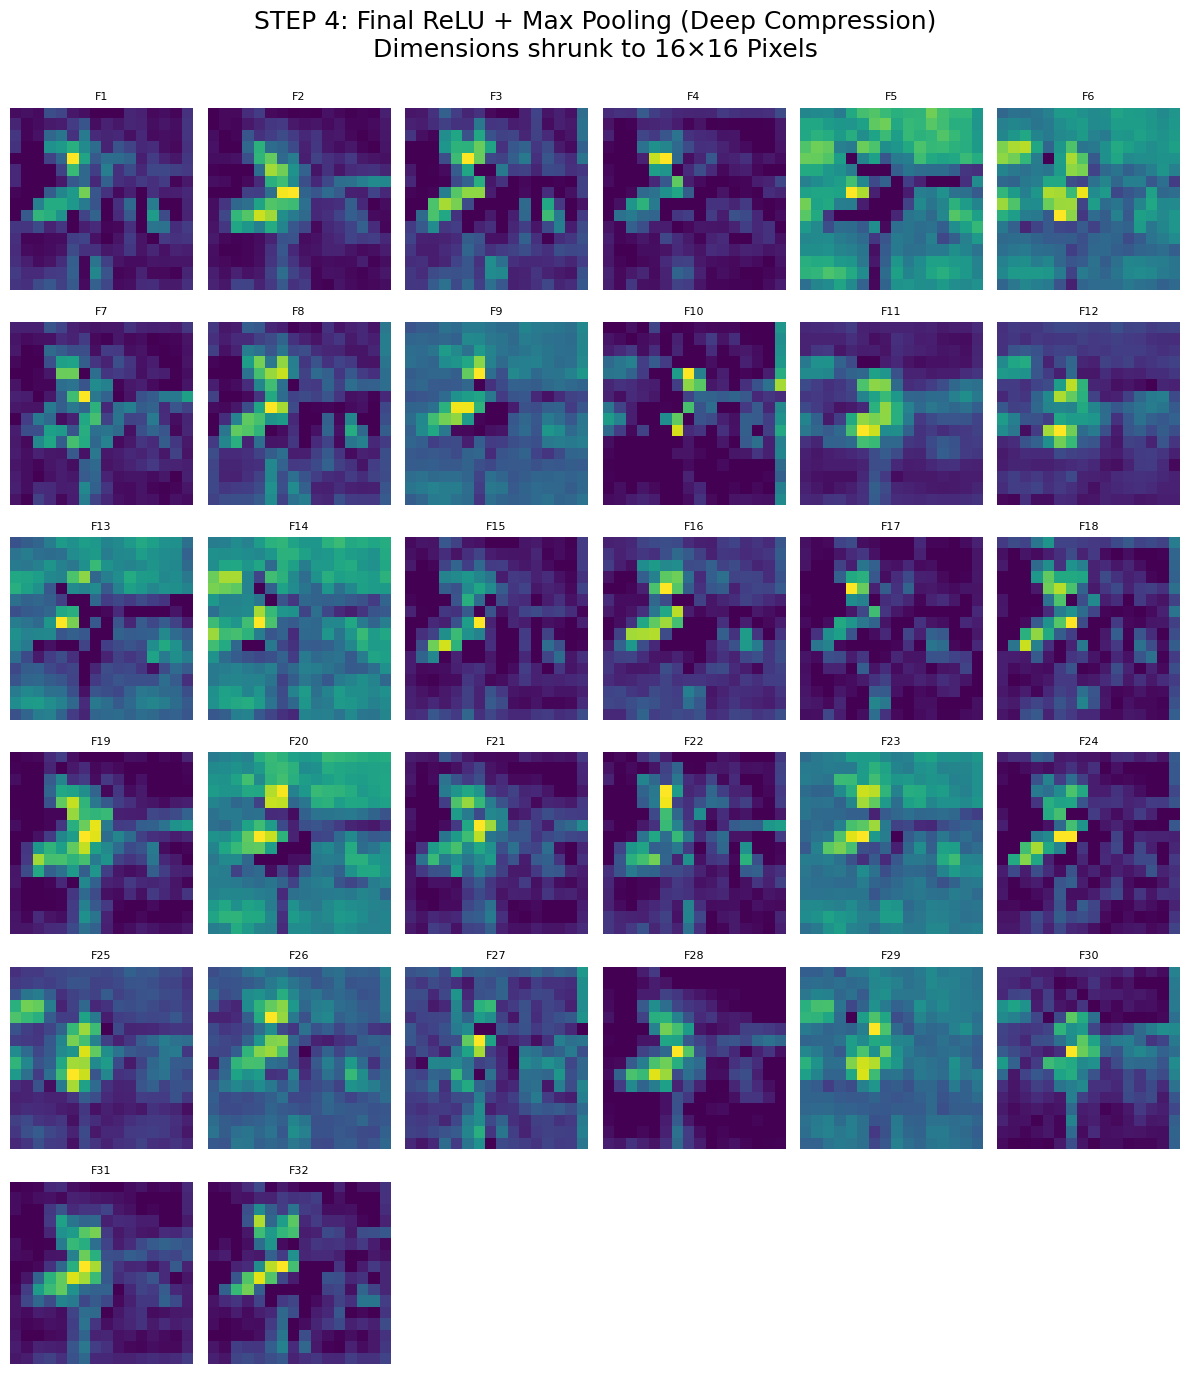

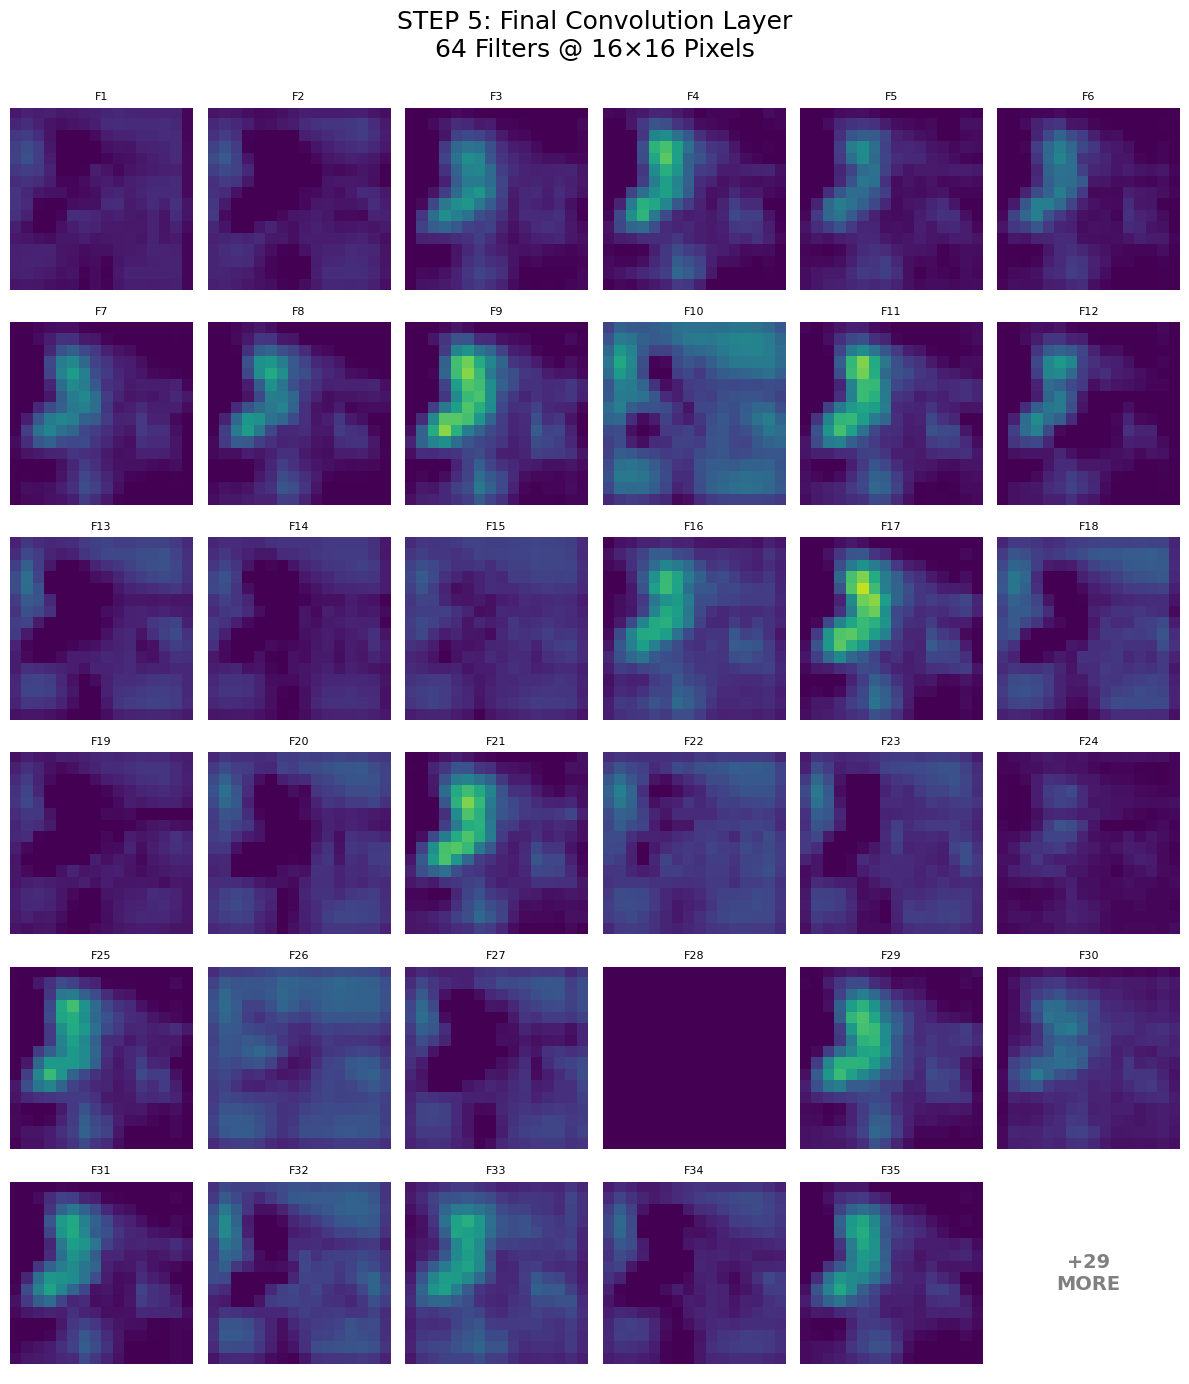

0.26, 0.24, 0.36, 0.45, 0.31, 0.28, 0.35, 0.36, 0.59, 0.92, 0.53, 0.25, 0.37, 0.28, 0.46, 0.68, 0.59, 0.5, 0.22, 0.42, 0.56, 0.6, 0.43, 0.18, 0.45, 0.74, 0.4, 0.0, 0.56, 0.43, 0.39, 0.59, 0.72, 0.35, 0.42, 0.8, 0.4, 0.26, 0.5, 0.46, 1.05, 0.57, 0.36, 0.43, 0.2, 0.43, 0.39, 0.6, 0.3, 0.21, 0.04, 0.13, 0.49, 0.55, 0.68, 0.39, 0.96, 0.53, 0.0, 0.48, 0.11, 0.58, 0.61, 0.35, 

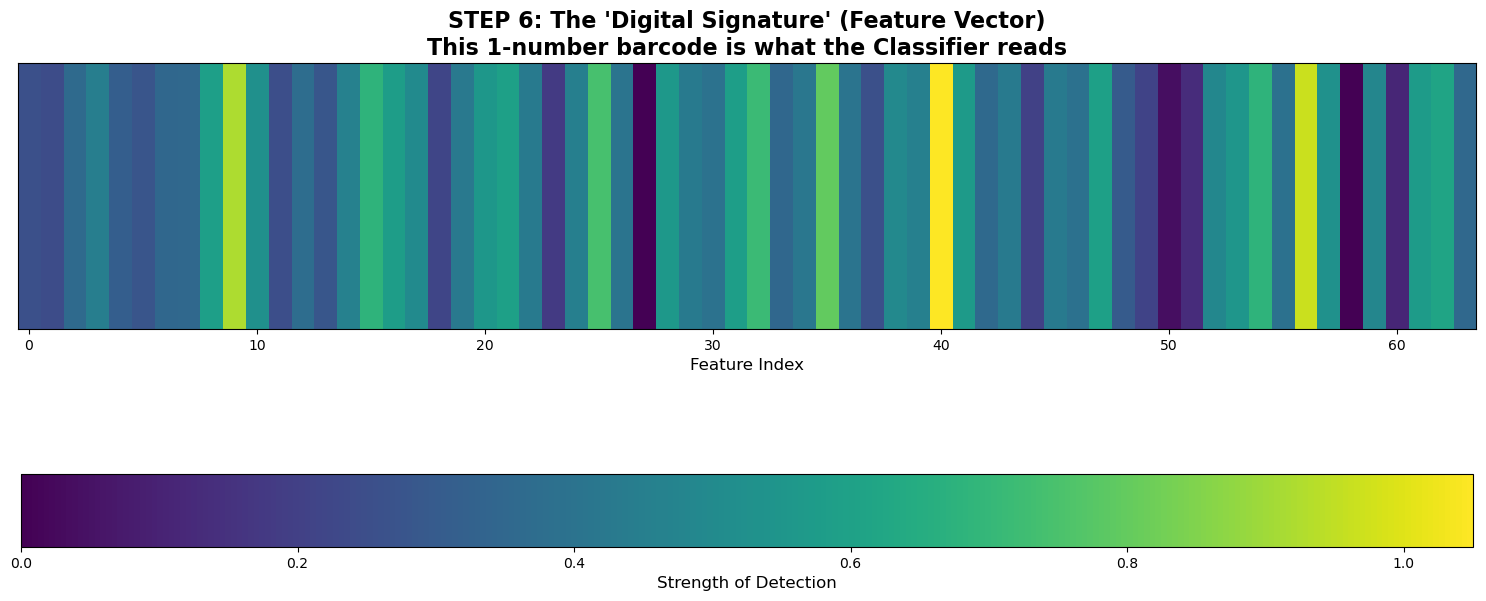

In [33]:
# --- 1. ORIGINAL PHOTO ---
h_og, w_og, _ = img_display.shape
plt.figure(figsize=(3, 3))
plt.imshow(img_display)
plt.axis("off")
plt.tight_layout()
#plt.savefig("image_full.pdf")
plt.show()

# --- 2. DECONSTRUCTED TENSOR ---
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
channel_titles = ["Red Channel", "Green Channel", "Blue Channel"]
cmaps = ["Reds", "Greens", "Blues"]
for i, (ax, t, cmap) in enumerate(zip(axes, channel_titles, cmaps)):
    channel_data = img_display[:, :, i]
    im = ax.imshow(channel_data, cmap=cmap)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
#plt.savefig("first_tensor_full.pdf")
plt.show()

# --- 3. LAYER 1: CONVOLUTION ---
first_layer_key = list(activations.keys())[0]
feat_early = activations[first_layer_key].squeeze(0)
f_count1, h1, w1 = feat_early.shape
make_filter_grid(feat_early,
    f"STEP 1: Convolution (Extraction)\n{f_count1} Filters @ {h1}×{w1} Pixels",
    "16_filters_full.pdf")

# --- 3.5 ReLU + MAX POOLING ---
with torch.no_grad():
    feat_relu = F.relu(torch.tensor(feat_early))
    feat_pooled = F.max_pool2d(feat_relu.unsqueeze(0), kernel_size=2, stride=2).squeeze(0)
f_count_p, h_p, w_p = feat_pooled.shape
make_filter_grid(feat_pooled,
    f"STEP 2: ReLU + Max Pooling (Compression)\nDimensions shrunk to {h_p}×{w_p} Pixels",
    "16_filters_pooled_full.pdf")

# --- 4. LAYER 2: DEEPER FEATURES ---
if len(activations) > 1:
    second_layer_key = list(activations.keys())[1]
    feat_deep = activations[second_layer_key].squeeze(0)
    f_count2, h2, w2 = feat_deep.shape
    make_filter_grid(feat_deep,
        f"STEP 3: Deeper Convolution\n{f_count2} Filters @ {h2}×{w2} Pixels",
        "32_filters_full.pdf")

    # --- 4.5 SECOND ReLU + MAX POOLING ---
    with torch.no_grad():
        feat_deep_relu = F.relu(torch.tensor(feat_deep))
        feat_deep_pooled = F.max_pool2d(feat_deep_relu.unsqueeze(0), kernel_size=2, stride=2).squeeze(0)
    f_count_p2, h_p2, w_p2 = feat_deep_pooled.shape
    make_filter_grid(feat_deep_pooled,
        f"STEP 4: Final ReLU + Max Pooling (Deep Compression)\nDimensions shrunk to {h_p2}×{w_p2} Pixels",
        "32_filters_pooled_full.pdf")

# --- 5. LAYER 3: FINAL FEATURE EXTRACTION ---
if len(activations) > 2:
    third_layer_key = list(activations.keys())[2]
    feat_final = activations[third_layer_key].squeeze(0)
    f_count3, h3, w3 = feat_final.shape

    with torch.no_grad():
        feat_final_relu = F.relu(feat_final)
    
    make_filter_grid(feat_final_relu,
        f"STEP 5: Final Convolution Layer\n{f_count3} Filters @ {h3}×{w3} Pixels",
        "64_filters_full.pdf",
        vmin=0, vmax=feat_final_relu.max().item())

    # --- 5.5 ADAPTIVE AVG POOL ---
    with torch.no_grad():
        feat_squashed = torch.mean(feat_final_relu.view(f_count3, -1), dim=1).numpy()


# --- BARCODE ---
vector_data = feat_squashed.reshape(1, -1)
plt.figure(figsize=(15, 6))
img = plt.imshow(vector_data, aspect='auto', cmap='viridis', vmin=0)
plt.title(f"STEP 6: The 'Digital Signature' (Feature Vector)\nThis {len(vector_data)}-number barcode is what the Classifier reads",
          fontsize=16, fontweight='bold')
plt.yticks([])
plt.xlabel("Feature Index", fontsize=12)
cbar = plt.colorbar(img, orientation='horizontal', pad=0.3)
cbar.set_label('Strength of Detection', fontsize=12)
for v in vector_data[0]:
    print(round(v, 2), end=", ")
plt.tight_layout()
#plt.savefig("final_feature_vector_barcode.pdf")
plt.show()

Finding Interesting Predictions

In [34]:
key_certain = lambda i: -abs(all_probs[i] - 0.5)  # most certain first
key_uncertain = lambda i: abs(all_probs[i] - 0.5)  # most uncertain first

Confident_FPs = sorted([i for i, l, p in zip(range(len(all_labels)), all_labels, all_probs) if (l == 0) & (p >= .75)], key=key_certain)
Confident_FNs = sorted([i for i, l, p in zip(range(len(all_labels)), all_labels, all_probs) if (l == 1) & (p <= .25)], key=key_certain)
Confident_TPs = sorted([i for i, l, p in zip(range(len(all_labels)), all_labels, all_probs) if (l == 1) & (p >= .75)], key=key_certain)
Confident_TNs = sorted([i for i, l, p in zip(range(len(all_labels)), all_labels, all_probs) if (l == 0) & (p <= .25)], key=key_certain)
FPs = sorted([i for i, l, p in zip(range(len(all_labels)), all_labels, all_probs) if (l == 0) & (p > .5)], key=key_certain)
FNs = sorted([i for i, l, p in zip(range(len(all_labels)), all_labels, all_probs) if (l == 1) & (p <= .5)], key=key_certain)
TPs = sorted([i for i, l, p in zip(range(len(all_labels)), all_labels, all_probs) if (l == 1) & (p > .5)], key=key_certain)
TNs = sorted([i for i, l, p in zip(range(len(all_labels)), all_labels, all_probs) if (l == 0) & (p <= .5)], key=key_certain)
Most_Uncertain = sorted(range(len(all_probs)), key=key_uncertain)


print(f"True Positives :   {len(TPs)}")
print(f"True Negatives :   {len(TNs)}")
print(f"False Positives:   {len(FPs)}")
print(f"False Negatives:   {len(FNs)}")
print(f"Confident True Positives :   {len(Confident_TPs)}")
print(f"Confident True Negatives :   {len(Confident_TNs)}")
print(f"Confident False Positives:   {len(Confident_FPs)}")
print(f"Confident False Negatives:   {len(Confident_FNs)}")

True Positives :   1461
True Negatives :   725
False Positives:   275
False Negatives:   54
Confident True Positives :   1275
Confident True Negatives :   443
Confident False Positives:   124
Confident False Negatives:   11


Setting Up LIME

In [35]:
explainer = lime_image.LimeImageExplainer()
MEAN_4D = np.array([0.485, 0.456, 0.406], dtype=np.float32).reshape(1, 1, 1, 3)
STD_4D  = np.array([0.229, 0.224, 0.225], dtype=np.float32).reshape(1, 1, 1, 3)

def predict_for_lime(images_np):
    """Takes a batch of (N, H, W, 3) numpy images in [0,1] and returns class probabilities."""
    x = images_np.astype(np.float32)
    if x.ndim == 3:
        x = x[np.newaxis, ...]
    x = (x - MEAN_4D) / STD_4D
    x = torch.tensor(x.transpose(0, 3, 1, 2), dtype=torch.float32).to(DEVICE)
    
    with torch.no_grad():
        logits = model(x).view(-1)
        probs_damage = torch.sigmoid(logits).cpu().numpy()
    
    return np.column_stack([1 - probs_damage, probs_damage])


def run_lime(img_np):
    return explainer.explain_instance(
        img_np, predict_for_lime,
        top_labels=2, hide_color=0, num_samples=5000, random_seed=42, num_features=10,
        segmentation_fn=lambda x: slic(x, n_segments=50, compactness=10, sigma=.5)
    )

def plot_lime_heatmap(ax, img_np, explanation):
    segments = explanation.segments
    local_exp = dict(explanation.local_exp[1])  # class 1 = damaged
    heatmap = np.zeros(segments.shape, dtype=np.float64)
    for seg_id, weight in local_exp.items():
        heatmap[segments == seg_id] = weight
    max_abs = max(abs(heatmap.min()), abs(heatmap.max()), 1e-8)
    heatmap_norm = heatmap / max_abs
    ax.imshow(img_np, alpha=0.4)
    im = ax.imshow(heatmap_norm, cmap='RdYlGn_r', alpha=0.6, vmin=-1, vmax=1)
    ax.set_title("LIME Explanation", fontsize=10)
    ax.axis("off")
    return im

def plot_original(ax, img_np, n, title="",desc = True):
    true_label = int(all_labels[n])
    pred_prob = all_probs[n]
    pred_class = 1 if pred_prob >= 0.5 else 0
    true_str = "Damaged" if true_label == 1 else "Undamaged"
    pred_str = "Damaged" if pred_class == 1 else "Undamaged"
    color = "green" if pred_class == true_label else "red"
    ax.imshow(img_np)

    if title != "":
        ax.set_title(f"{title}\nTrue: {true_str} | Pred: {pred_str} ({pred_prob:.2f})", fontsize=10, color=color)
        
    ax.axis("off")

Segmenting the Image into Superpixels

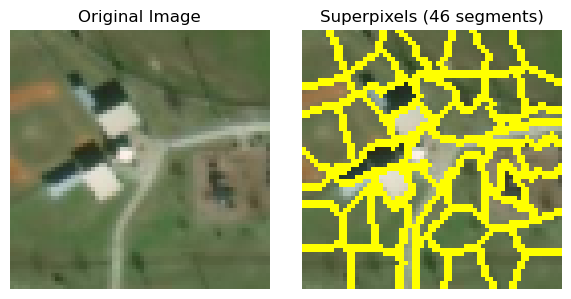

In [36]:
idx = 1
img_np =  get_display_image(all_images[idx])

segments = slic(img_np, n_segments=50, compactness=10, sigma=.5)

fig, axes = plt.subplots(1, 2, figsize=(6, 3))

axes[0].imshow(img_np)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(mark_boundaries(img_np, segments, color=(1, 1, 0), mode='thin'))
axes[1].set_title(f"Superpixels ({segments.max() + 1} segments)")
axes[1].axis("off")

plt.tight_layout()
#plt.savefig("superpixels.pdf")
plt.show()

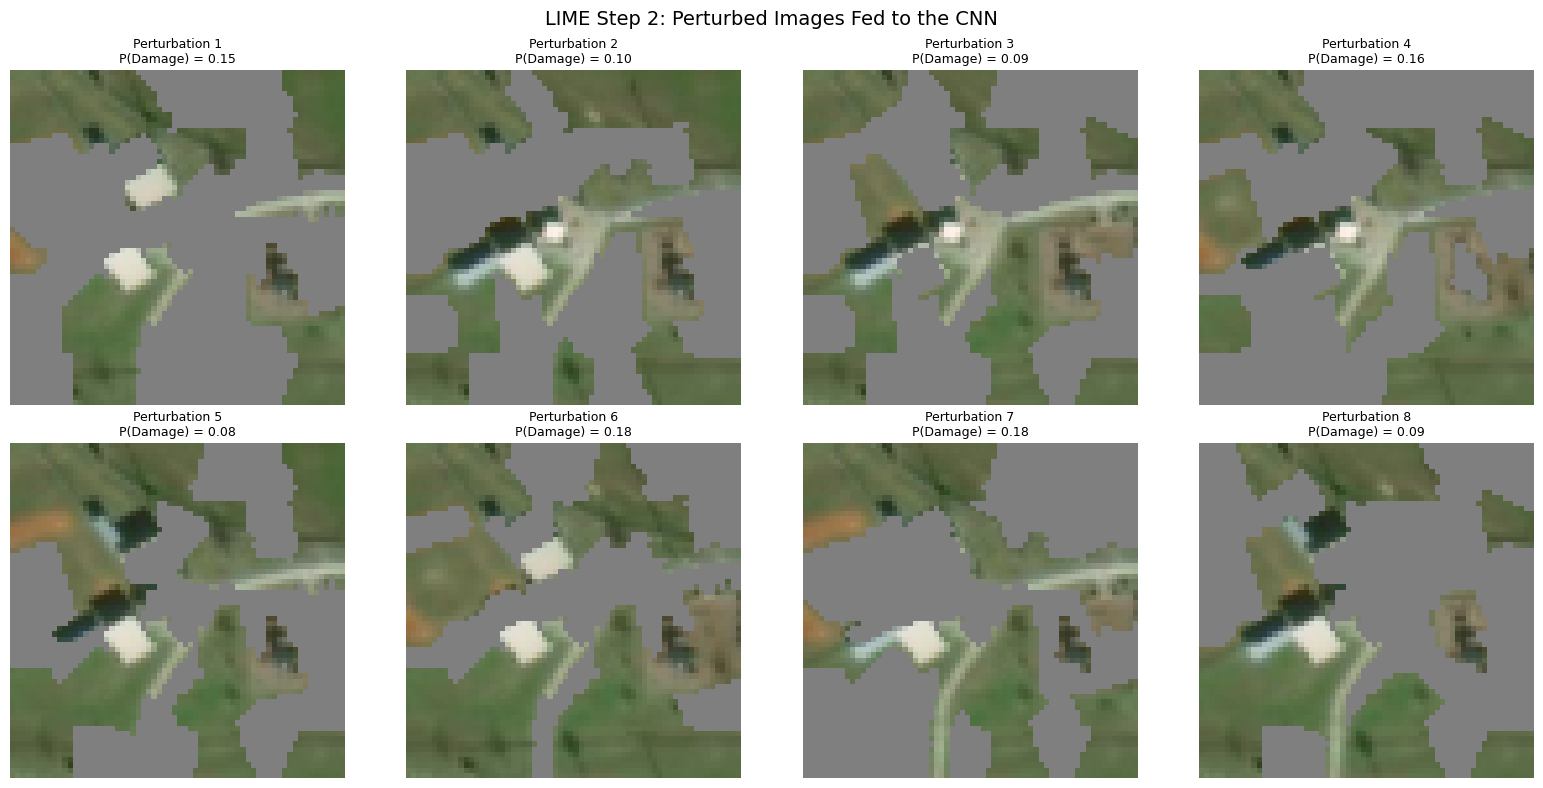

Perturbation  SP_0  SP_1  SP_2  SP_3  SP_4  SP_5 ... P(Damaged)
     Image 1     0     1     1     1     0     0 ...       0.15
     Image 2     0     1     1     0     1     1 ...       0.10
     Image 3     1     1     1     0     1     0 ...       0.09
     Image 4     0     1     1     0     0     0 ...       0.16
     Image 5     0     1     1     1     1     0 ...       0.08
     Image 6     1     1     1     0     0     1 ...       0.18
     Image 7     1     1     1     1     1     0 ...       0.18
     Image 8     1     0     1     1     1     1 ...       0.09


In [37]:
idx = 1
img_np = get_display_image(all_images[idx])
segments = slic(img_np, n_segments=50, compactness=10, sigma=0.5)
n_segments = segments.max() + 1

np.random.seed(42)
n_perturbations = 8  # how many to show

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

binary_vectors = []
predictions = []

for i in range(n_perturbations):
    mask = np.random.binomial(1, 0.5, size=n_segments)
    
    perturbed = img_np.copy()
    for seg_id in range(n_segments):
        if mask[seg_id] == 0:
            perturbed[segments == seg_id] = 0.5  # gray out
    
    pred = predict_for_lime(np.array([perturbed]))[0][1]  # P(damaged)
    
    binary_vectors.append(mask)
    predictions.append(pred)
    
    axes[i].imshow(perturbed)
    axes[i].set_title(f"Perturbation {i+1}\nP(Damage) = {pred:.2f}", fontsize=9)
    axes[i].axis("off")

plt.suptitle("LIME Step 2: Perturbed Images Fed to the CNN", fontsize=14)
plt.tight_layout()
#plt.savefig("lime_perturbations.pdf")
plt.show()

df = pd.DataFrame(binary_vectors, columns=[f"SP_{i}" for i in range(n_segments)])
df.insert(0, "Perturbation", [f"Image {i+1}" for i in range(n_perturbations)])
df["P(Damaged)"] = [f"{p:.2f}" for p in predictions]

cols_to_show = ["Perturbation"] + [f"SP_{i}" for i in range(6)] + ["...", "P(Damaged)"]
df["..."] = "..."
print(df[cols_to_show].to_string(index=False))

Applying LIME Across Different Image Types

  0%|          | 0/5000 [00:00<?, ?it/s]

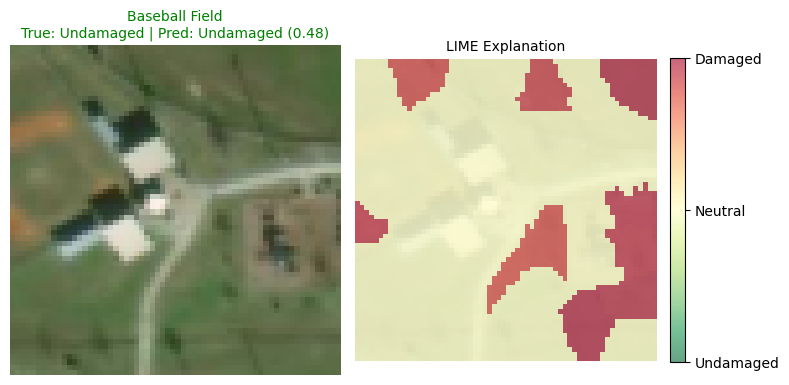

  0%|          | 0/5000 [00:00<?, ?it/s]

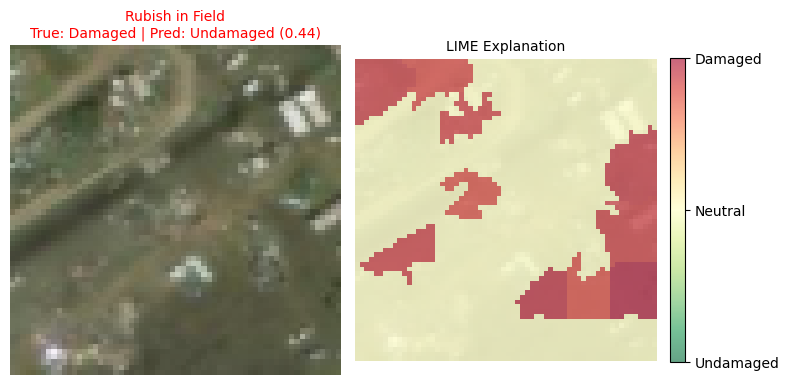

  0%|          | 0/5000 [00:00<?, ?it/s]

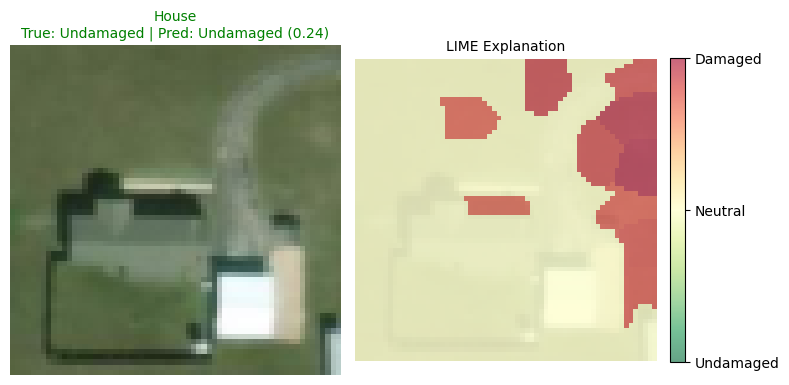

  0%|          | 0/5000 [00:00<?, ?it/s]

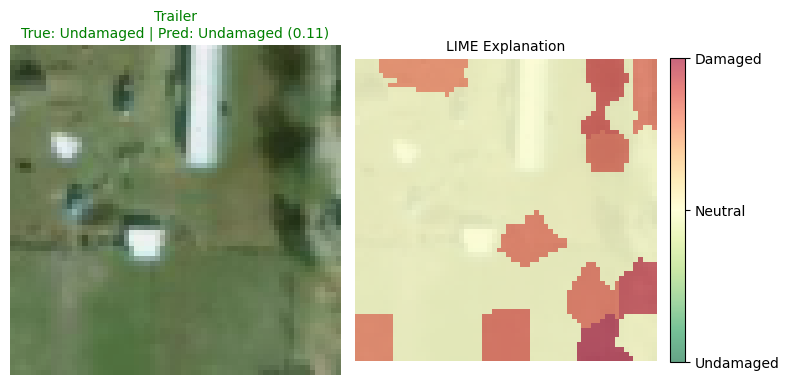

  0%|          | 0/5000 [00:00<?, ?it/s]

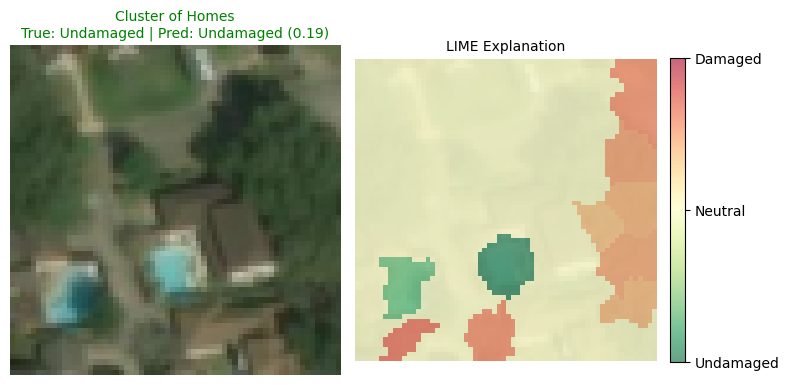

  0%|          | 0/5000 [00:00<?, ?it/s]

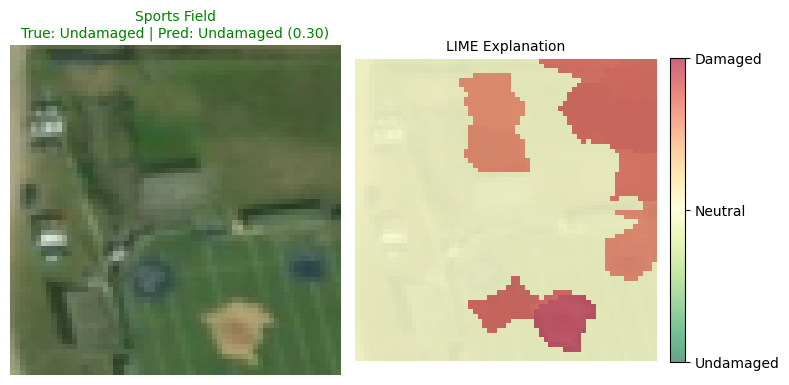

  0%|          | 0/5000 [00:00<?, ?it/s]

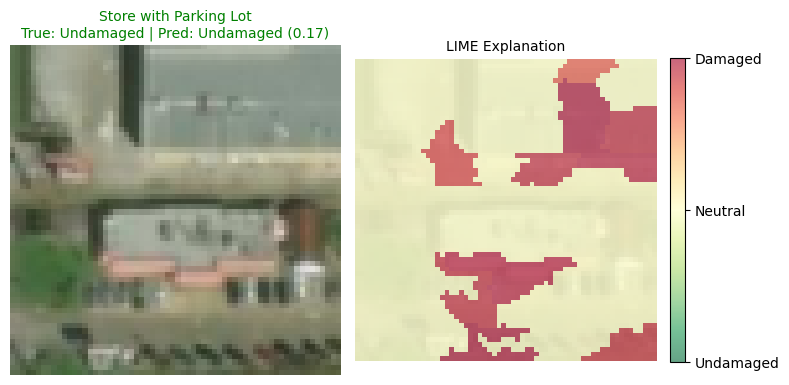

  0%|          | 0/5000 [00:00<?, ?it/s]

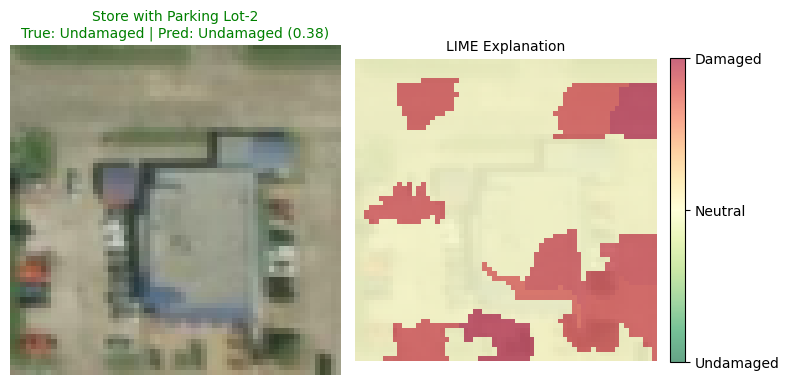

  0%|          | 0/5000 [00:00<?, ?it/s]

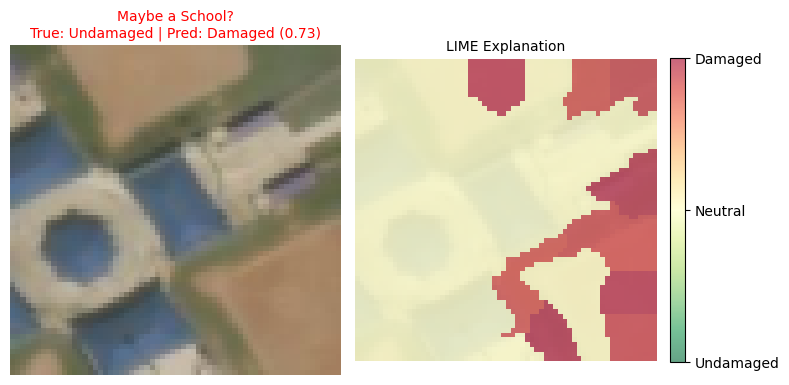

  0%|          | 0/5000 [00:00<?, ?it/s]

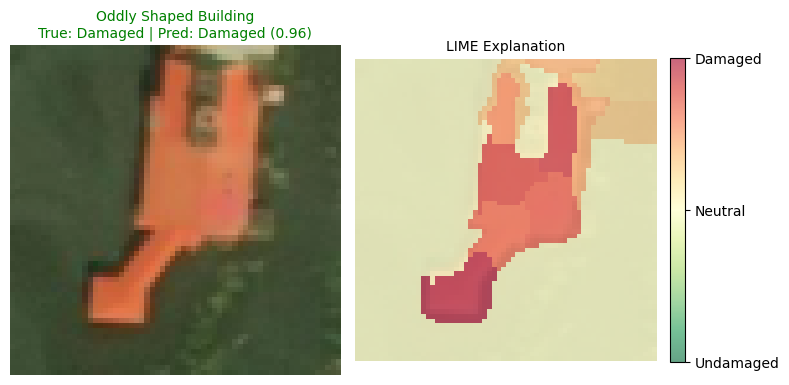

  0%|          | 0/5000 [00:00<?, ?it/s]

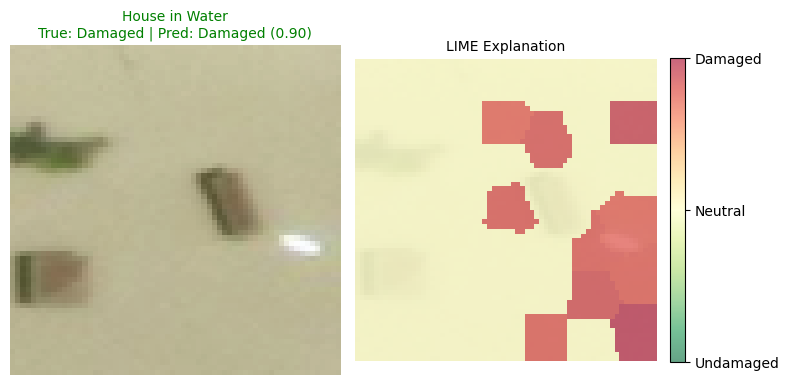

  0%|          | 0/5000 [00:00<?, ?it/s]

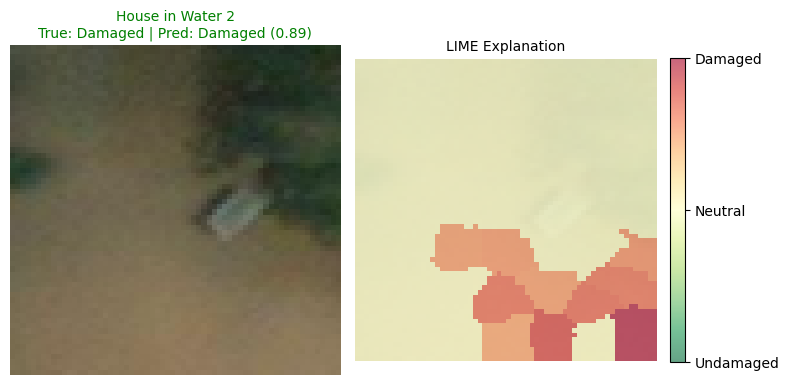

  0%|          | 0/5000 [00:00<?, ?it/s]

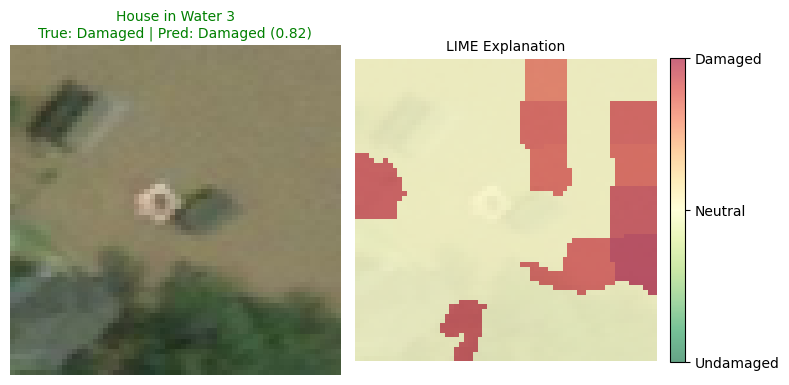

  0%|          | 0/5000 [00:00<?, ?it/s]

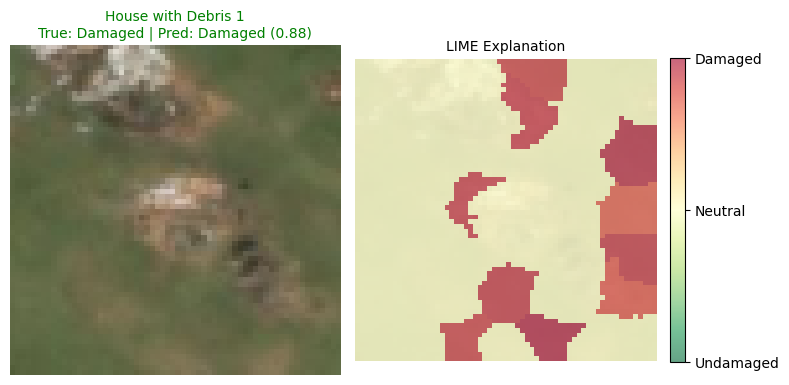

  0%|          | 0/5000 [00:00<?, ?it/s]

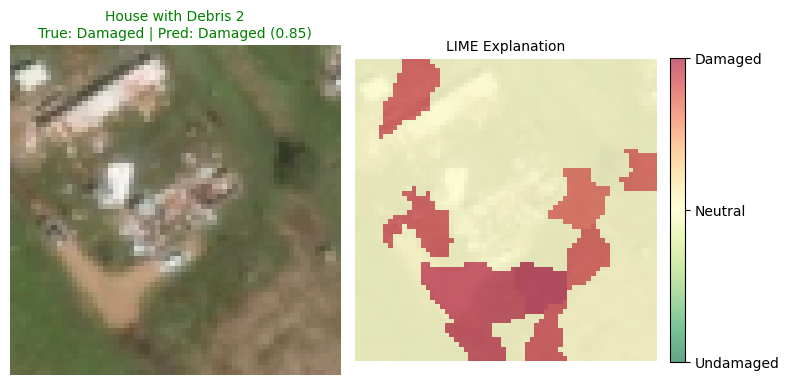

  0%|          | 0/5000 [00:00<?, ?it/s]

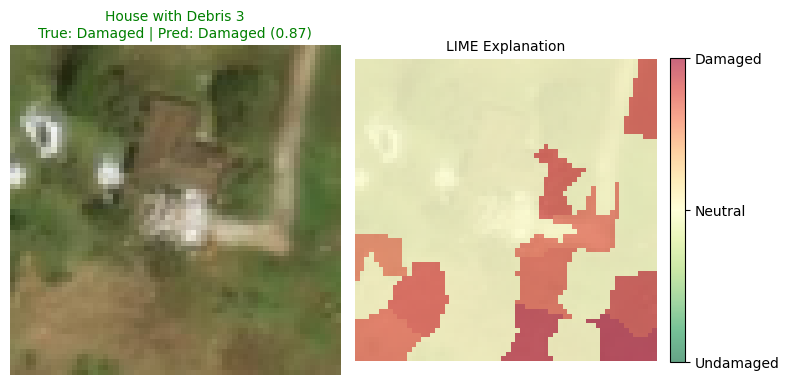

In [38]:
cases = {
    "Baseball Field": 1,
    "Rubish in Field":2395,
    "House": 0,
    "Trailer": 23,
    "Cluster of Homes": 628,
    "Sports Field": 305,
    "Store with Parking Lot": 793,
    "Store with Parking Lot-2": 794,
    "Maybe a School?": 954,
    "Oddly Shaped Building": 1040,
    "House in Water": 1331,
    "House in Water 2": 1332,
    "House in Water 3": 1333,
    "House with Debris 1": 2377,
    "House with Debris 2": 2381,
    "House with Debris 3": 2382,
}

for case_name, n in cases.items():
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    img_np = get_display_image(all_images[n])
    explanation = run_lime(img_np)

    plot_original(axes[0], img_np, n, title=case_name)
    im = plot_lime_heatmap(axes[1], img_np, explanation)

    cbar = fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
    cbar.set_ticks([-1, 0, 1])
    cbar.set_ticklabels(["Undamaged", "Neutral", "Damaged"])
    plt.tight_layout()
    #plt.savefig("select_images_lime_"+str(n)+"_"+case_name+".pdf")
    plt.show()

Before and After — Same Building, Pre- and Post-Hurricane

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

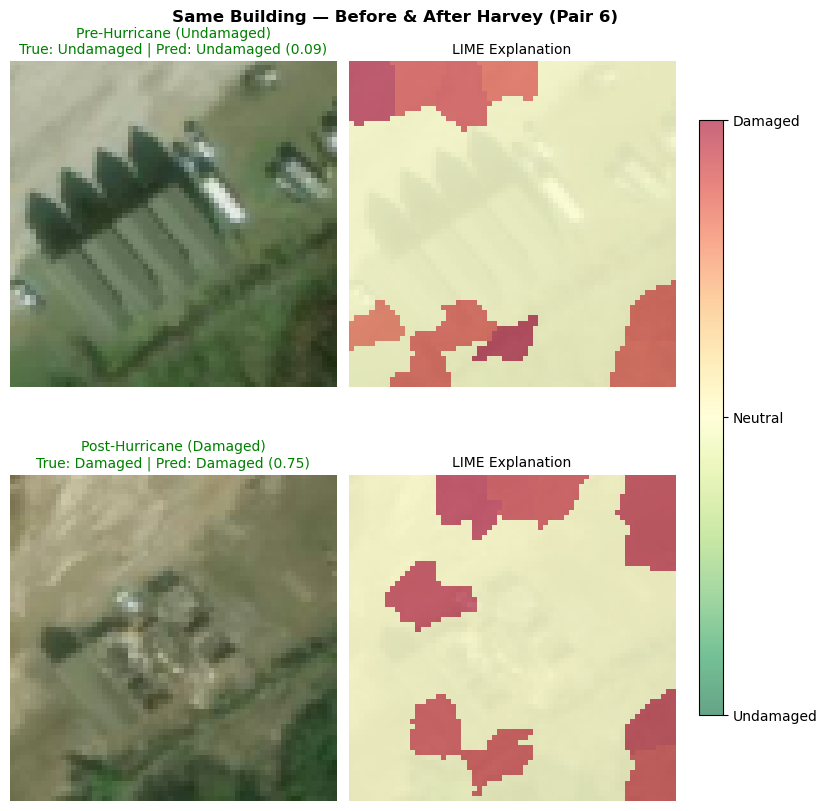

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

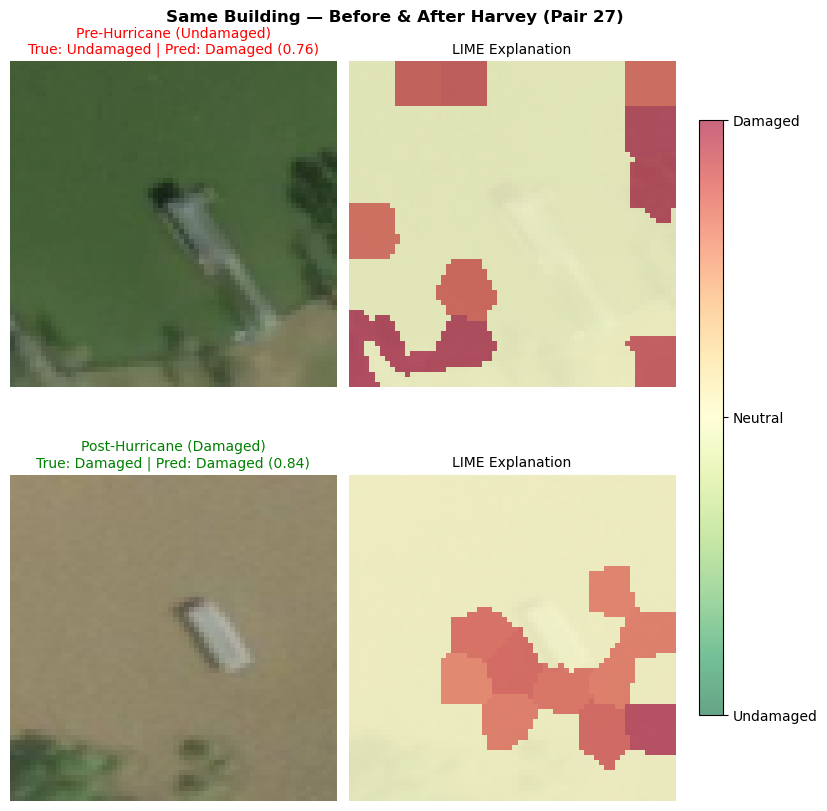

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

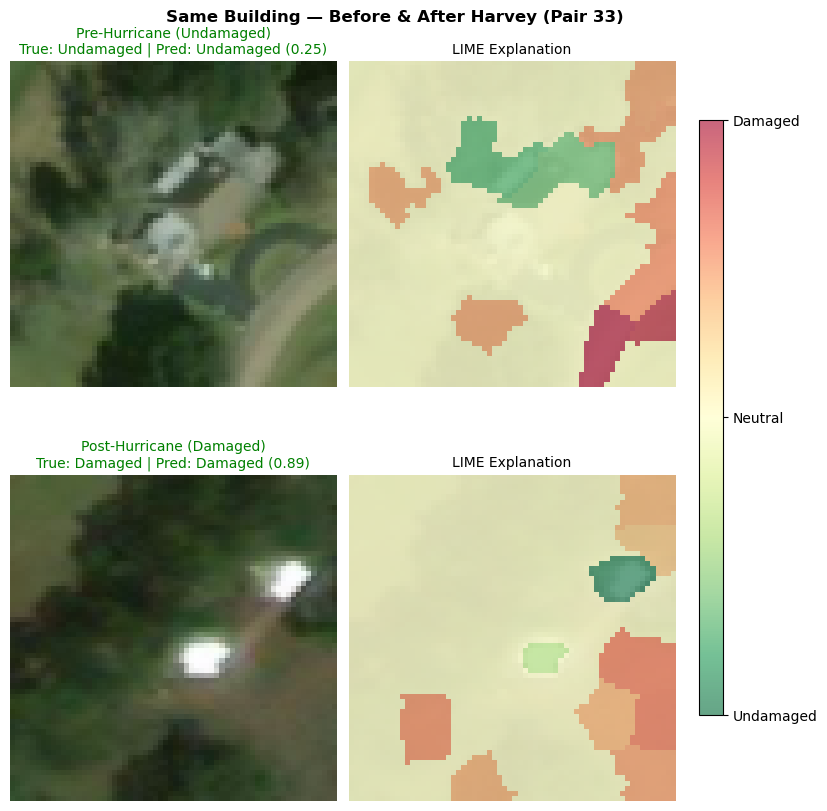

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

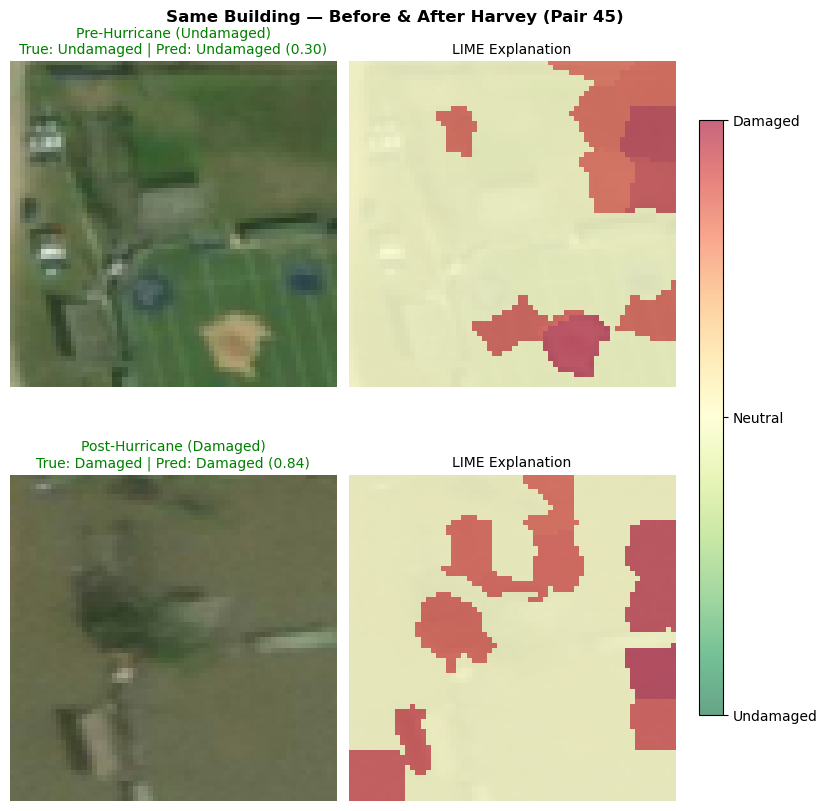

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

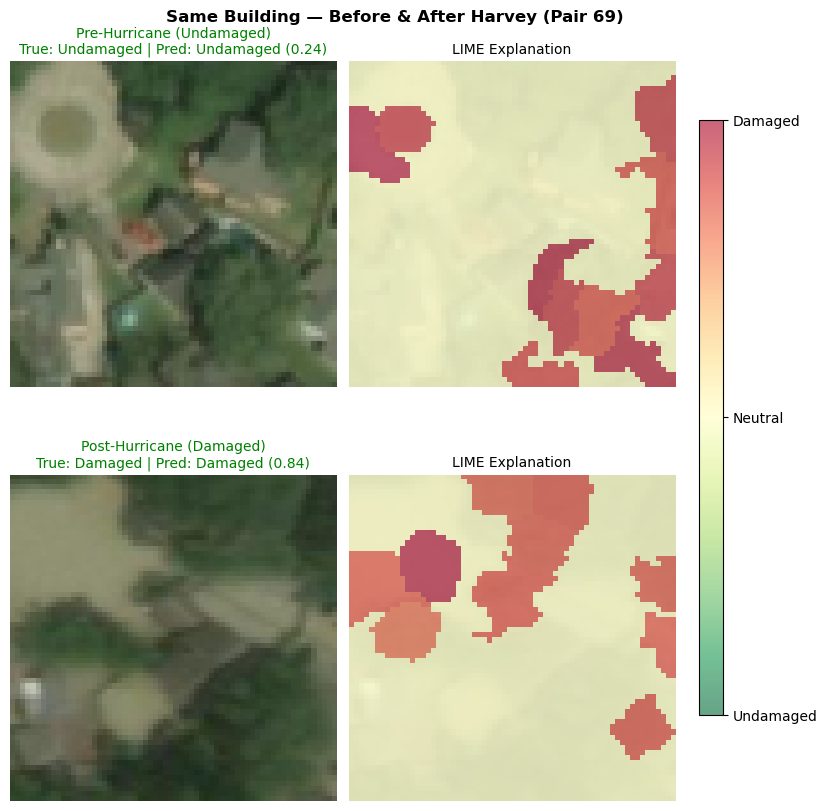

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

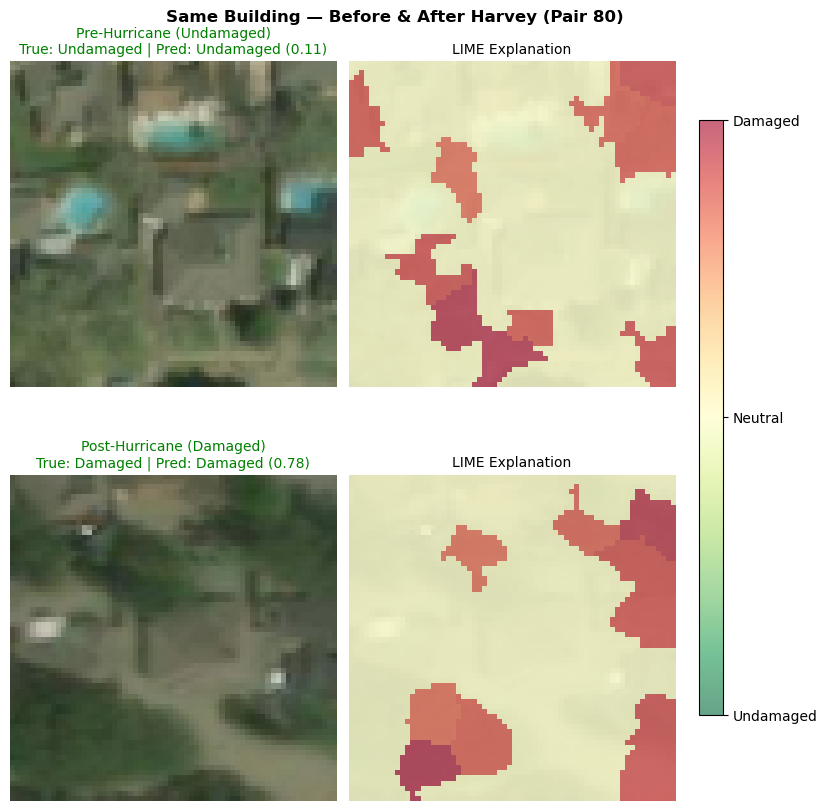

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

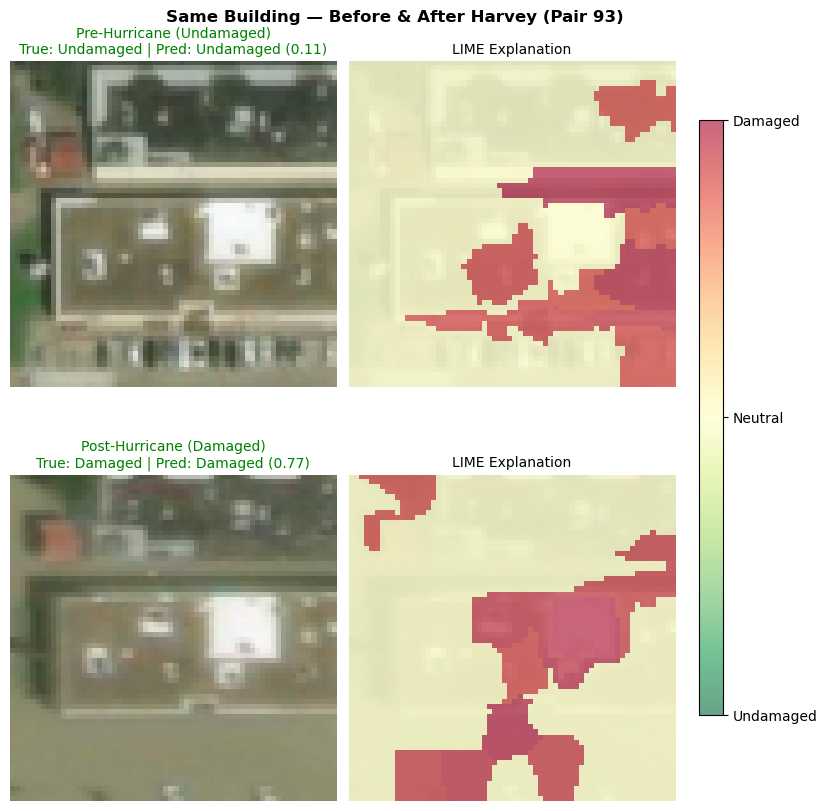

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

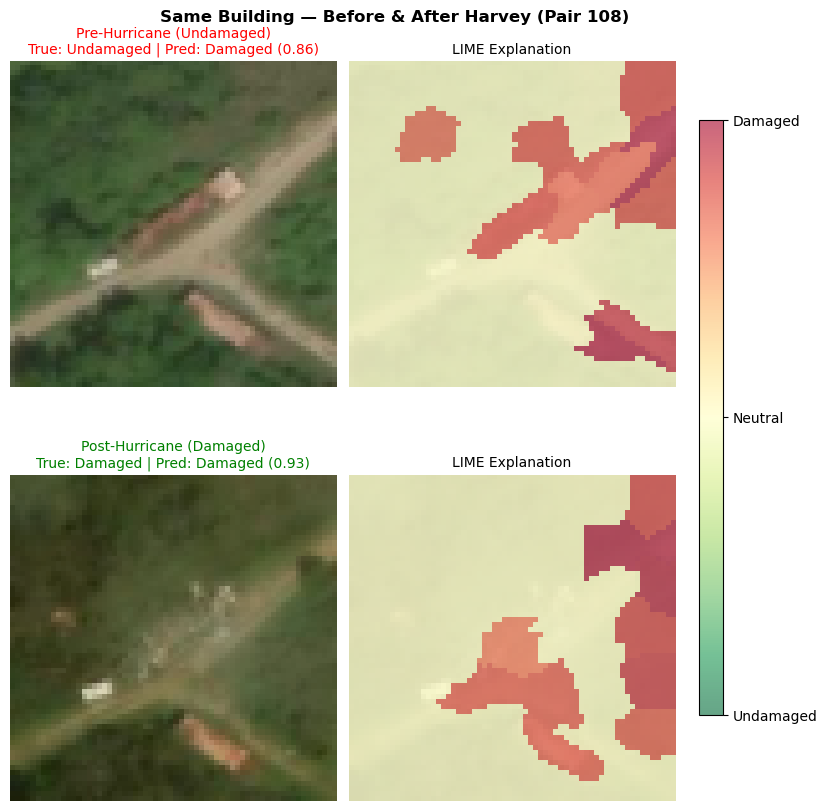

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

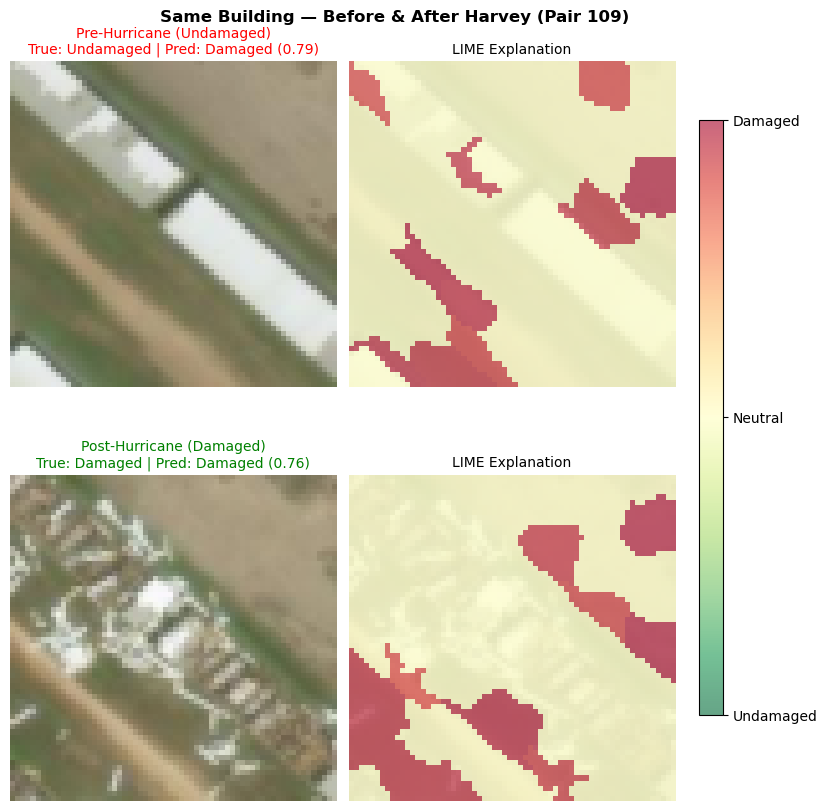

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

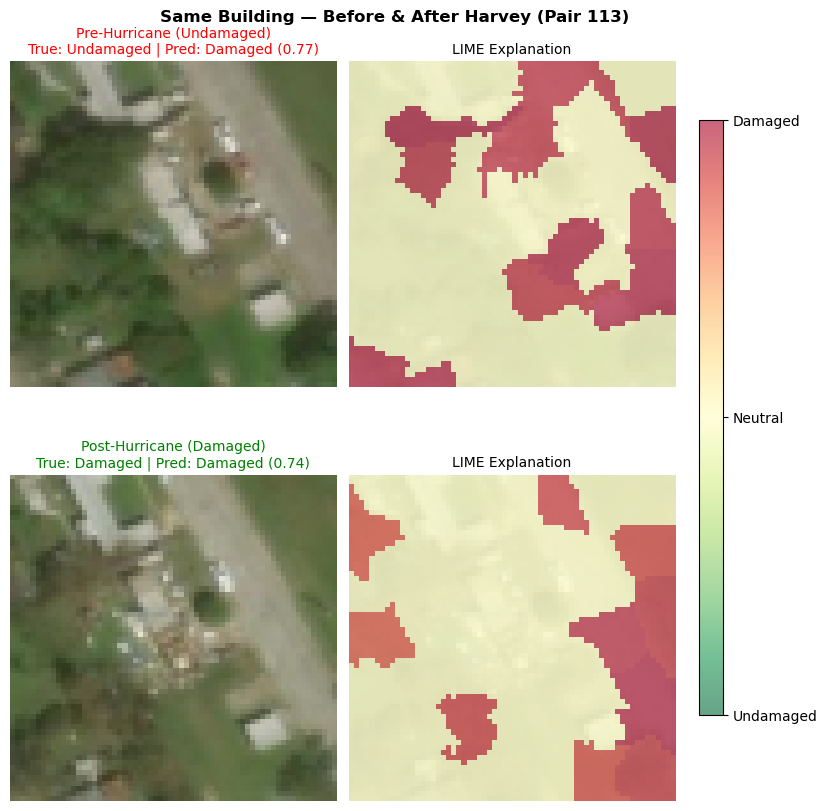

In [39]:
idx = 0
for p in pairs:
    if idx in [6, 27, 33, 45, 69, 108, 80, 93, 109, 113]:
        l1 = p['a_no_damage_idx']
        l2 = p['b_damage_idx']
        fig, axes = plt.subplots(2, 2, figsize=(8, 8.5))
        row_labels = ["Pre-Hurricane (Undamaged)", "Post-Hurricane (Damaged)"]

        for loc, n in enumerate([l1, l2]):
            img_np = get_display_image(all_images[n])
            explanation = run_lime(img_np)

            plot_original(axes[loc, 0], img_np, n, title=row_labels[loc])
            im = plot_lime_heatmap(axes[loc, 1], img_np, explanation)

        plt.tight_layout()
        fig.subplots_adjust(right=0.85)
        cbar_ax = fig.add_axes([0.88, 0.15, 0.03, 0.7])
        cbar = fig.colorbar(im, cax=cbar_ax)
        cbar.set_ticks([-1, 0, 1])
        cbar.set_ticklabels(["Undamaged", "Neutral", "Damaged"])

        fig.suptitle(f"Same Building — Before & After Harvey (Pair {idx})",
                     fontsize=12, fontweight="bold")
        #plt.savefig("before_after_lime_"+str(l1)+".pdf")
        plt.show()
    idx += 1